In [124]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
import numpy as np


dir = Path(r"C:/Users/nadia/Documents/")
name = "DST_BIL54.csv"
df = pd.read_csv(dir/name)

In [125]:
# "Total" angives i millioner 
df["total"] = df["total"]/(10**6)
# Object to datetime 
df["time"] = pd.to_datetime(df["time"])

In [126]:
# Creating a "year" column with decimal values for months
df["year"] = df["time"].dt.year + (df["time"].dt.month - 1) / 12

Vi koncenterer os herfra om variablerne "total" og "year":

* y:  total car registrations
* x:  datetime, year and month 

In [127]:
x = df["year"]
y = df["total"]

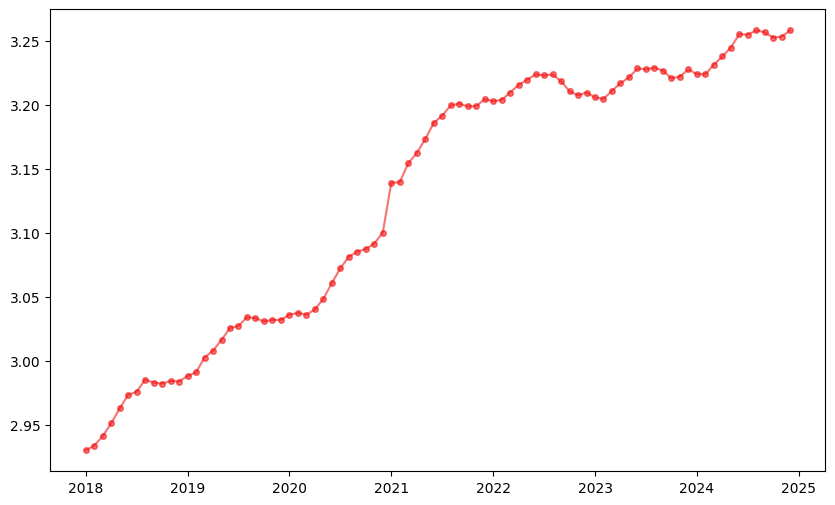

In [128]:
plt.figure(figsize=(10,6))
plt.plot(x, y, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(x, y, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)


In [129]:
cut = "2024-01-01"
cut = pd.to_datetime(cut)


df_train = df[df["time"] < cut]
df_test  = df[df["time"] >= cut]


In [130]:
x_train = df_train["year"]
y_train = df_train["total"]
x_test = df_test["year"]
y_test = df_test["total"]

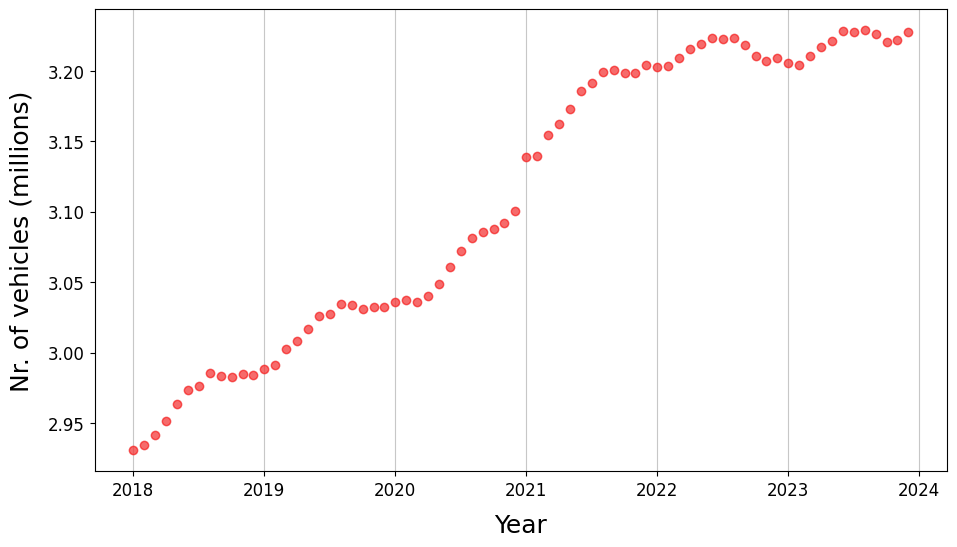

In [131]:
plt.figure(figsize=(11,6))
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "lightgrey", alpha = 0.4)
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "red", alpha = 0.55)
plt.grid(axis = "x", alpha = 0.7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


GLM:

$Y_t = \theta_1 + \theta_2 \cdot x_t + \epsilon_t $

In [132]:
# Design matrix for training data
A = np.column_stack([np.ones(len(x_train)), x_train])

In [133]:
print("Determinant:",np.linalg.det(A.T @ A))
print("Rang: ", np.linalg.matrix_rank(A))

Determinant: 15549.000004242993
Rang:  2


In [134]:
c = np.linalg.solve(A.T@A, A.T@y_train)
print(c)

[-1.10355428e+02  5.61445562e-02]


In [135]:
c1 = np.linalg.lstsq(A, y_train, rcond=None)[0]   # mest stabilt
c2 = np.linalg.pinv(A) @ y_train                  # bruger Moore–Penrose pseudoinvers
c1, c2

(array([-1.10355428e+02,  5.61445562e-02]),
 array([-1.10355428e+02,  5.61445562e-02]))

In [136]:
y_pred = c[0] + c[1] * x_test
y_train_pred = c[0] + c[1] * x_train

In [150]:
y_pred.shape, y_test.shape

((12,), (12,))

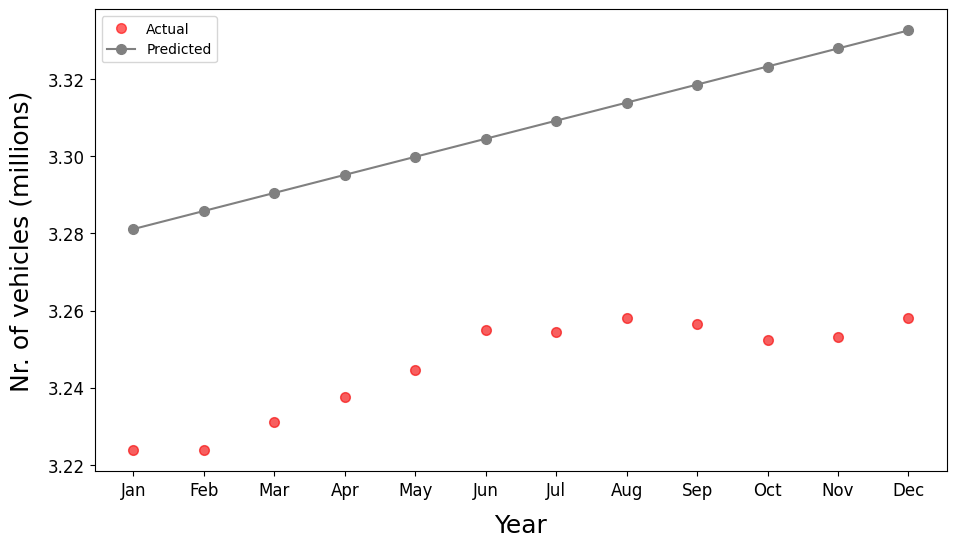

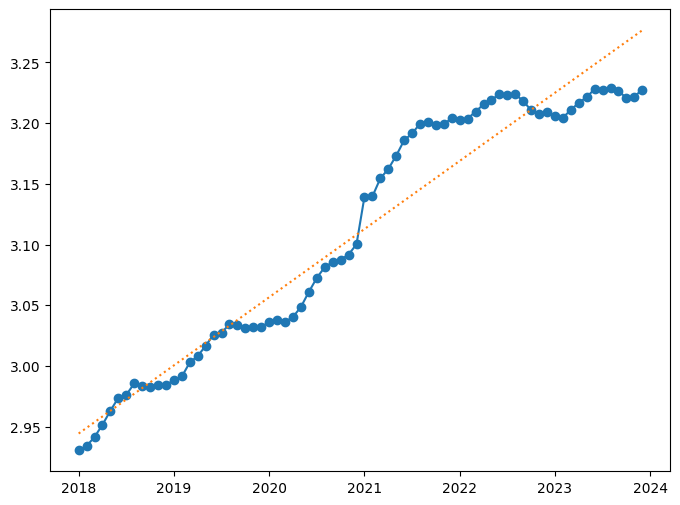

In [151]:
x_ind = np.arange(len(y_test)) # 0,1,2,...,11
plt.figure(figsize=(11,6))
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "lightgrey", alpha = 0.4, markersize = 7)
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "red", alpha = 0.6, label="Actual", markersize = 7)
plt.plot(x_ind, y_pred, label="Predicted", marker="o", linestyle="-", color = "grey", markersize = 7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(
    ticks = range(len(y_test)),
    labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize = 12
)

plt.yticks(fontsize = 12)

plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(x_train, y_train, marker="o", linestyle="-", label="Train")
plt.plot(x_train, y_train_pred, label="Train Predicted", marker="", linestyle=":", markersize  = 7)